In [113]:
import sys

from matplotlib import pyplot as plt
%matplotlib widget
import numpy as np
from scipy import signal
from scipy.signal import find_peaks

filename = "raw2024_07_23T16_23_401.txt"
accelCharacter = '4'


bytesToGs = 4/0x7FFF # +-4 gs per half the range of bytes
bytesToAngularFreq = 250/0x7FFF # +-250 rad/s per half the range of bytes

flightInformation = {
    "raw2024_07_23T16_23_401.txt" : {
        "range" : np.arange(133100,138500),
        "accelCharacter" : '4',
        "offset_indices" : np.array([132420,132420,133018,133895,134317,135030,135651,136205,136889])
    },
        
}
file = open(filename,'rb')
lines = file.readlines()
# print(lines)
properlines = [line for line in lines if (len(line) == 18 and line[-2] == bytearray(accelCharacter,"ascii")[0])]
accelx = np.array([int.from_bytes(line[0:2],"big",signed=True) for line in properlines])
accely = np.array([int.from_bytes(line[2:4],"big",signed=True) for line in properlines])
accelz = np.array([int.from_bytes(line[4:6],"big",signed=True) for line in properlines])
temp = np.array([int.from_bytes(line[6:8],"big",signed=False) for line in properlines])
gyrox = np.array([int.from_bytes(line[8:10],"big",signed=True) for line in properlines])
gyroy = np.array([int.from_bytes(line[10:12],"big",signed=True) for line in properlines])
gyroz = np.array([int.from_bytes(line[12:14],"big",signed=True) for line in properlines])
micros = np.array([int.from_bytes(line[14:16],"big",signed=False) for line in properlines])

In [127]:
diff_micros = np.diff(micros)

1019
-509
1019
-1018
1533
-2041
1529
-3060
1024
-3574
1019
-4083
1529
-5102
1529
-6121
1019
-6630
1529
-7649
1019
-8158
1528
-9176
1019
-9685
1529
-10704
1019
-11213
1529
-12232
1019
-12741
1019
-13250
1529
-14269
1529
-15288
1019
-15797
1529
-16816
1529
-17835
1019
-18344
1019
-18853
1021
-19364
1531
-20385
1022
-20897
1529
-21916
1020
-22426
1536
-23452
1019
-23961
1020
-24471
1529
-25490
1019
-25999
1020
-26509
1019
-27018
1019
-27527
1019
-28036
1022
-28548
1019
-29057
1020
-29567
1529
-30586
1019
-31095
1532
-32117
1530
-33137
1021
-33648
1528
-34666
1528
-35684
1529
-36703
1023
-37216
1529
-38235
1529
-39254
1020
-39764
1019
-40273
1019
-40782
1530
-41802
1533
-42825
1528
-43843
1019
-44352
1529
-45371
1021
-45882
1019
-46391
1533
-47414
1528
-48432
1023
-48945
1021
-49456
1529
-50475
1529
-51494
1020
-52004
1529
-53023
1023
-53536
1533
-54559
1528
-55577
1020
-56087
1533
-57110
1019
-57619
1019
-58128
1019
-58637
1021
-59148
1020
-59658
1529
-60677
1531
-61698
1533
-62721
1019
-

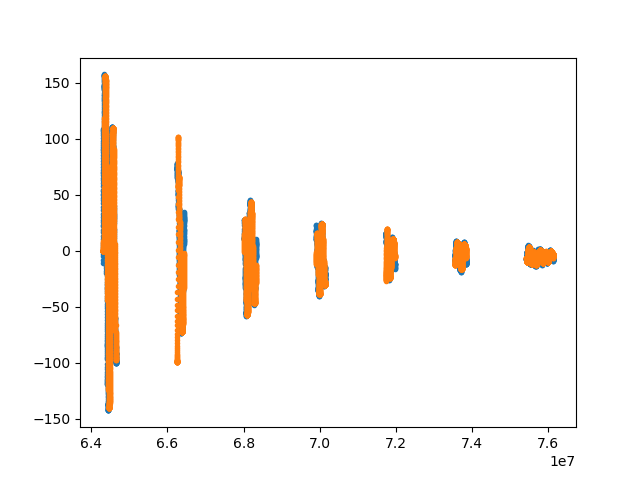

In [ ]:
offset = 0x10000
count = 0
offset_indices = flightInformation["raw2024_07_23T16_23_401.txt"]["offset_indices"]
skip_reduction = 0
micros_data = np.zeros(micros.size)

for i in range(len(micros) - 1):
    delta = micros[i+1] - micros[i]
    count_offset = np.sum(offset_indices==i)

    micros_data[i] = micros[i] + offset * (count + count_offset)
    if count_offset > 0:
        print(count_offset)
        count = count + count_offset
    if delta < -50000:
        count = count + 1

    if ((delta < 5000) and (delta > 750)):
        print(delta)
        skip_reduction -= (delta - 510)
        print(skip_reduction)
    
    micros_data[i] += skip_reduction






gyro_data = gyroy[flightInformation["raw2024_07_23T16_23_401.txt"]["range"]]*bytesToAngularFreq
micros_data = micros_data[flightInformation["raw2024_07_23T16_23_401.txt"]["range"]]
alt_micros_data = np.copy(micros_data)

plt.close()
plt.figure()
plt.plot(micros_data,gyro_data,'.')
sos = signal.butter(9,80,fs=4000,output="sos")
filt = signal.sosfilt(sos,gyro_data)
plt.plot(micros_data,filt,'.')

# filtered_gyro_data = np.abs(np.diff(filt,3)*10)
# peaks, _ = find_peaks(filtered_gyro_data,prominence=5,distance=offset/300)
# plt.plot(micros_data[:-3],filtered_gyro_data,'.')
# plt.plot(micros_data[peaks], filtered_gyro_data[peaks], "x")

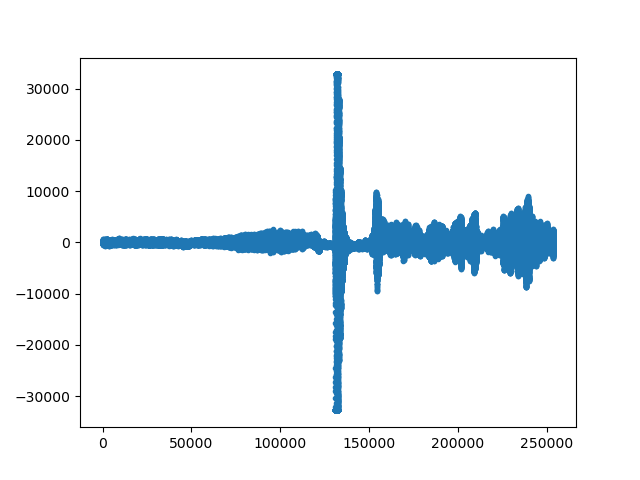

In [116]:
plt.close()
plt.figure()
plt.plot(gyroy,'.')

In [3]:

micros = np.array([int.from_bytes(line[14:16],"big",signed=False) for line in properlines])
offset = 0x10000
count = 0
manualCount = np.zeros(len(micros))
manualCount[132420] = 2
manualCount[133018] = 1
manualCount[133895] = 1
manualCount[134317] = 1
manualCount[135030] = 1
manualCount[135651] = 1
manualCount[136205] = 1
for i in range(len(micros) - 1):
    delta = micros[i+1] - micros[i]
    micros[i] = micros[i] + offset * (count + manualCount[i])
    if manualCount[i] > 0:
        count = count + manualCount[i]
    if delta < -50000:
        count = count + 1
    # if i >1:
        # print(micros[i] - micros[i -1 ])

NameError: name 'time' is not defined

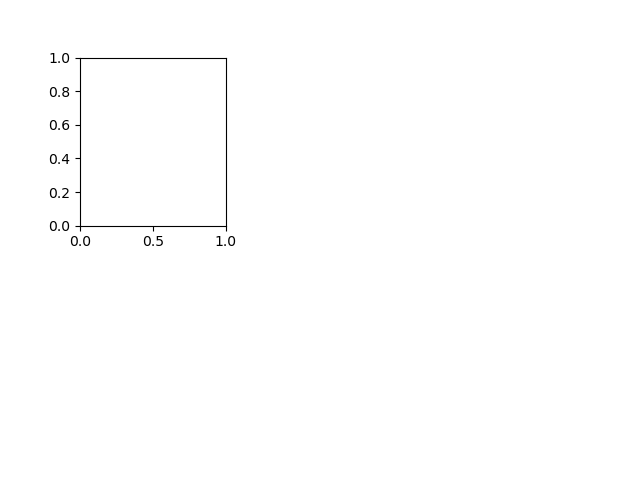

In [4]:
plt.close()
plt.figure()
plt.subplot(231)
plt.scatter(time,accelx*bytesToGs)
plt.title("accelx")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.subplot(232)
plt.scatter(time,accely*bytesToGs)
plt.title("accely")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.subplot(233)
plt.scatter(time,accelz*bytesToGs)
plt.title("accelz")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.subplot(234)
plt.scatter(time,gyrox*bytesToAngularFreq)
plt.title("gyrox")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
plt.subplot(235)
plt.scatter(time,gyroy*bytesToAngularFreq)
plt.title("gyroy")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
plt.subplot(236)
plt.scatter(time,gyroz*bytesToAngularFreq)
plt.title("gyroz")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
plt.show()

In [6]:
data_condition = (micros > 72e6) & (micros < 74e6)
second_derivative = np.diff(gyroy[data_condition],2)
diff_condition =  np.abs(second_derivative) > 1000

In [7]:
second_derivative.size

3127

In [8]:
gyroy[data_condition][:-2][diff_condition]

array([   843,   -466, -27699, -28658,  -1666,   -761,   9571,   -985,
        -1889,  -6623,  -7560, -32372, -32211, -32351, -31780, -18850,
       -18279, -11044, -10357,  -7088,  -6203,    567,   1019,   5750,
        28643,  29311,  20500,  19690, -32768, -32768,  28343,  28718,
       -27945, -27887,     30,   -220,   3557, -11207, -11263,   4401])

In [9]:
micros[data_condition][:-2][diff_condition].size

40

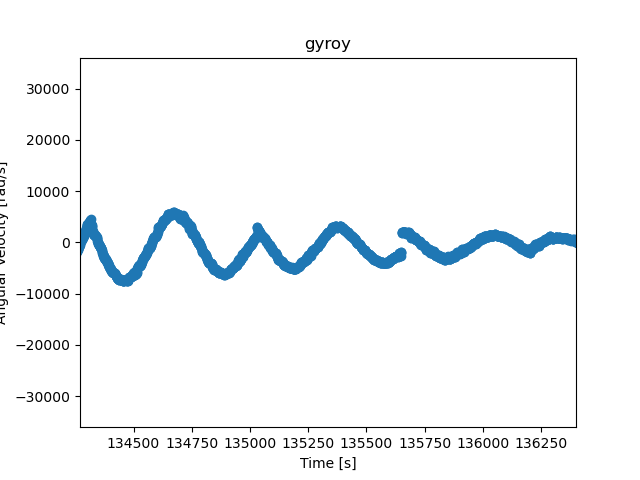

In [10]:
plt.close()
plt.figure()
plt.scatter(np.arange(len(gyroy)),gyroy)
plt.xlim(1.3427e5,1.364e5)
plt.title("gyroy")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
# plt.scatter(micros[data_condition][:-2][diff_condition]*1e-6,gyroy[data_condition][:-2][diff_condition])
plt.show()

In [11]:
from scipy.optimize import curve_fit

t_start = 72.965
time = micros*1e-6-t_start
data_condition = (time >=0) & (time <=1.25)
gyro_offset = 2

def f(t,omega,tau,A,phi):
    return A*np.exp(-t/tau)*np.sin(t*omega - phi)

fit = curve_fit(f, time[data_condition],gyroy[data_condition]*bytesToAngularFreq+gyro_offset,[27,0.7,300,0])

In [12]:
fit[0]

array([ 2.73611121e+01,  7.22430556e-01,  2.32260999e+02, -7.47705573e-02])

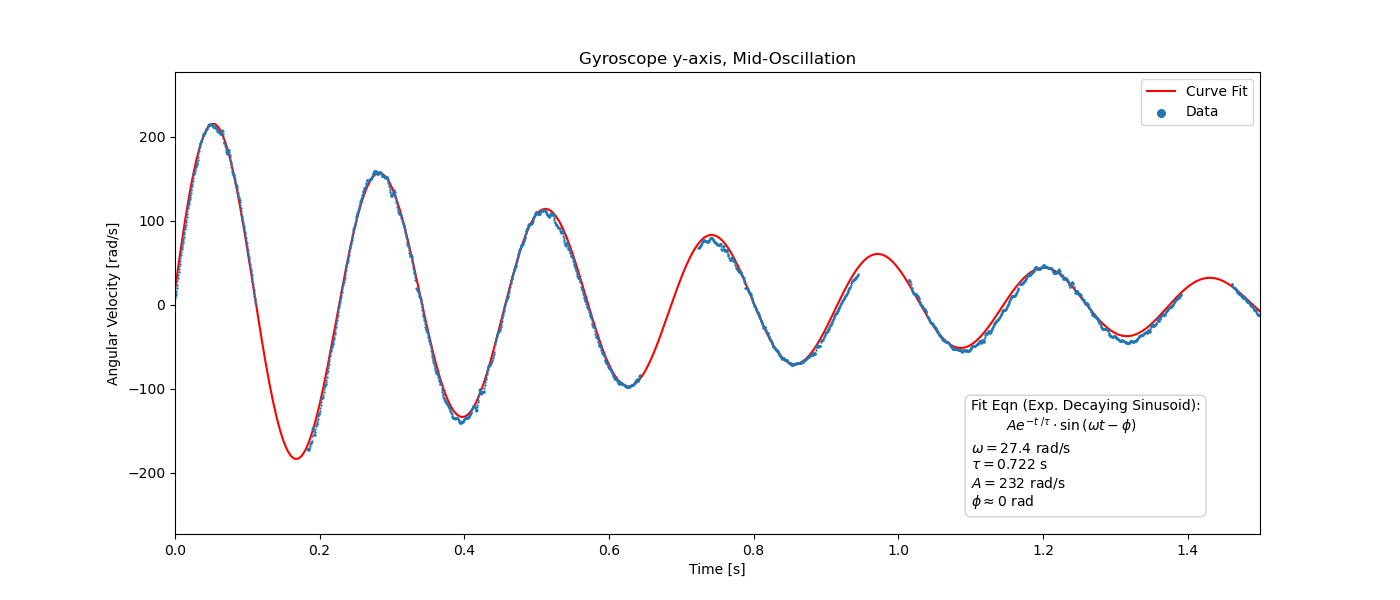

In [13]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Gyroscope y-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
t = np.linspace(0, 2,400)
plt.plot(t, fit[0][2]*np.exp(-t/fit[0][1])*np.sin(t*fit[0][0]-fit[0][3]),'r')
plt.scatter(time,gyroy*bytesToAngularFreq+gyro_offset,s=0.5,zorder=2)
legend = plt.legend(["Curve Fit","Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[1]._sizes = [30]
plt.gca().text(1.1, -240, 'Fit Eqn (Exp. Decaying Sinusoid):\n\t$Ae^{-t\ /\\tau}\cdot\sin{(\omega t -\phi)}$\n$\omega=27.4\ \mathrm{rad/s}$\n$\\tau=0.722\ \mathrm{s}$\n$A=232\ \mathrm{rad/s}$\n$\phi\\approx 0\ \mathrm{rad}$', color='black', bbox=dict(facecolor='none', edgecolor='lightgrey', boxstyle='round,pad=0.4'))
plt.show()

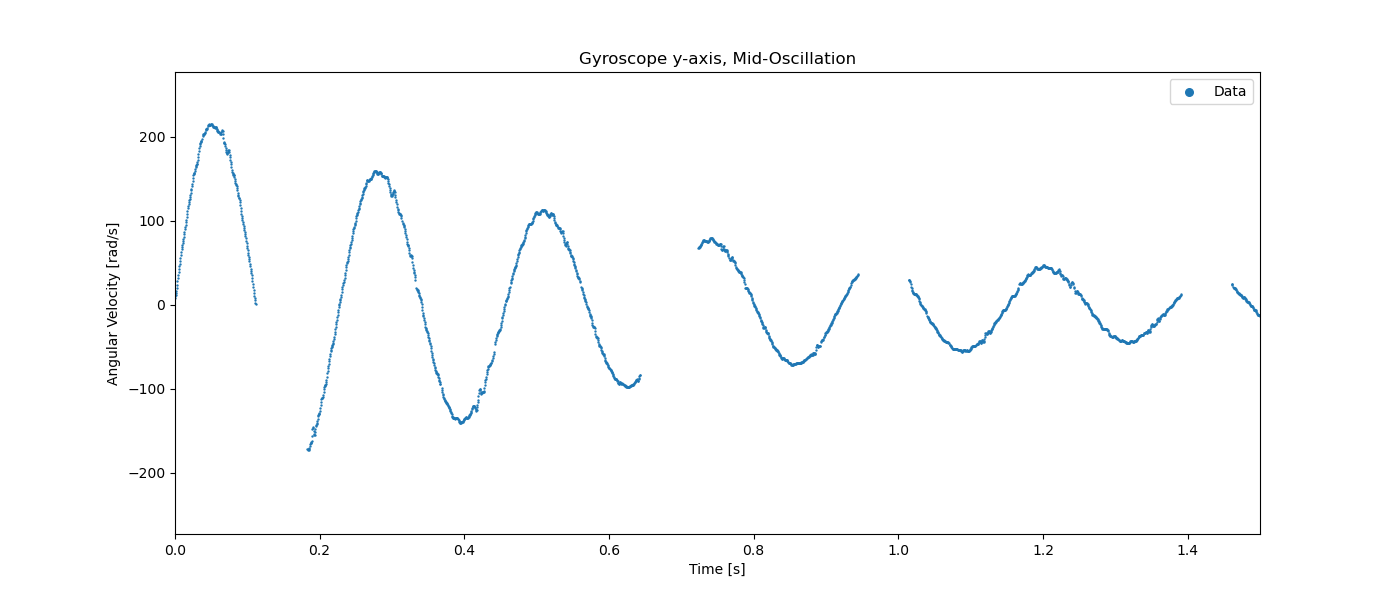

In [14]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Gyroscope y-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,gyroy*bytesToAngularFreq+gyro_offset,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()

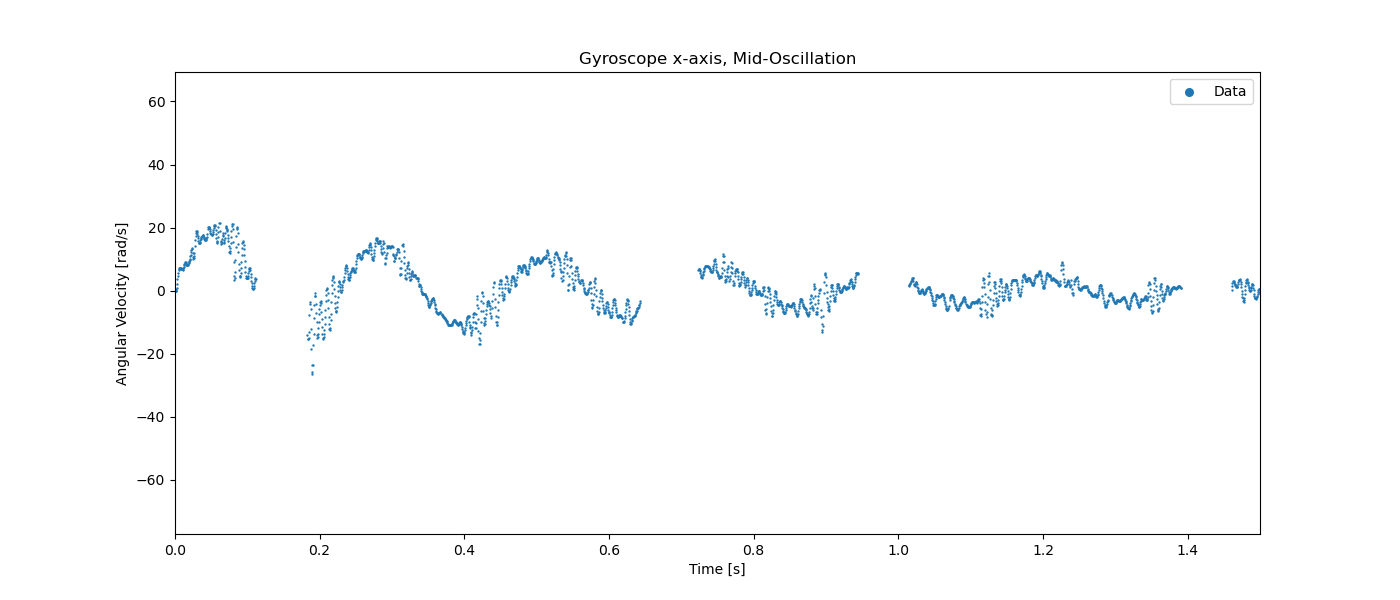

In [15]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Gyroscope x-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,gyrox*bytesToAngularFreq+gyro_offset,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()

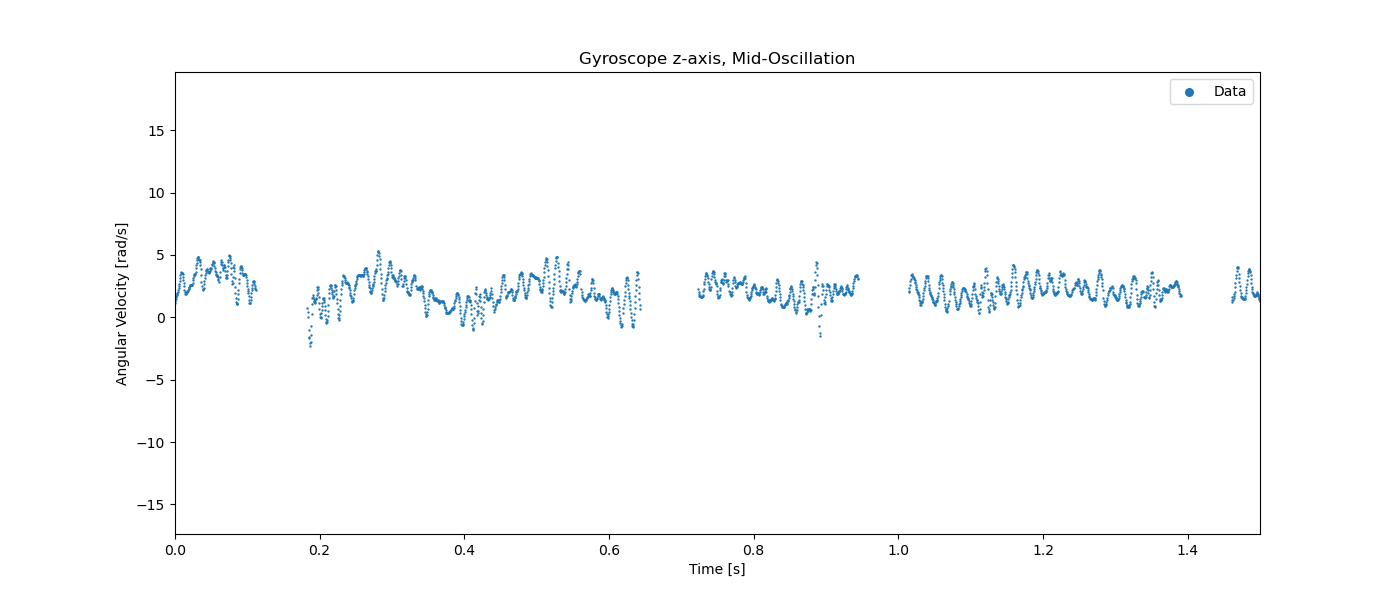

In [16]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Gyroscope z-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,gyroz*bytesToAngularFreq+gyro_offset,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()

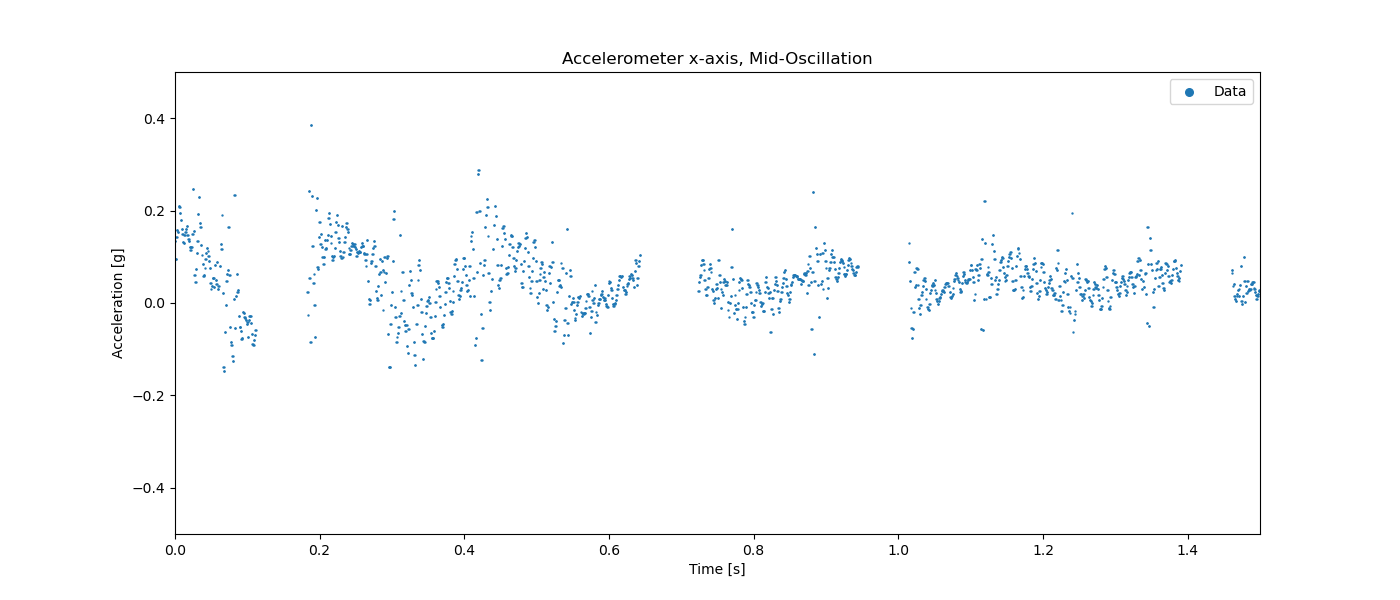

In [17]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Accelerometer x-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.ylim(-0.5,0.5)
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,accelx*bytesToGs,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()

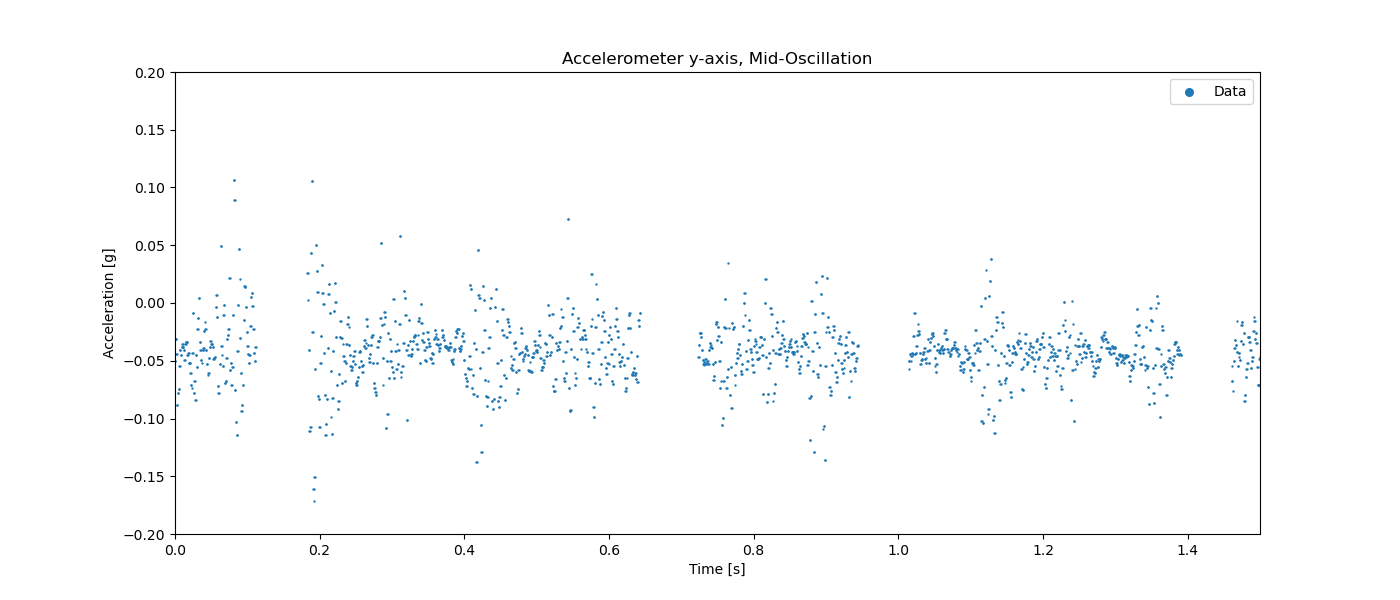

In [18]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Accelerometer y-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.ylim(-0.2,0.2)
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,accely*bytesToGs,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()

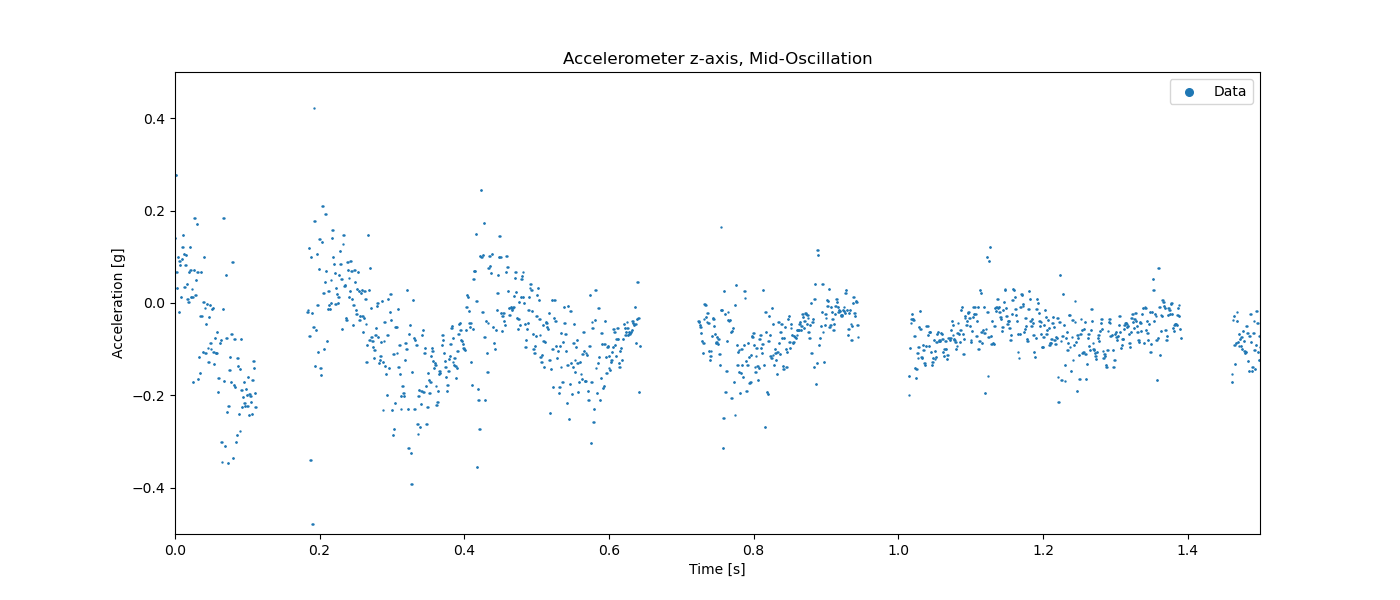

In [19]:
plt.close()
plt.figure(figsize=(14,6))
plt.xlim(0,1.5)
plt.title("Accelerometer z-axis, Mid-Oscillation")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.ylim(-0.5,0.5)
t = np.linspace(0, 2,400)
# plt.plot(t, fit[0][2]*np.exp(-(t-fit[0][3])/fit[0][1])*np.sin(t*fit[0][0]-fit[0][4]),'r')
plt.scatter(time,accelz*bytesToGs,s=0.5,zorder=2)
legend = plt.legend(["Data"], scatterpoints=1, fontsize=10)
legend.legend_handles[0]._sizes = [30]
plt.show()